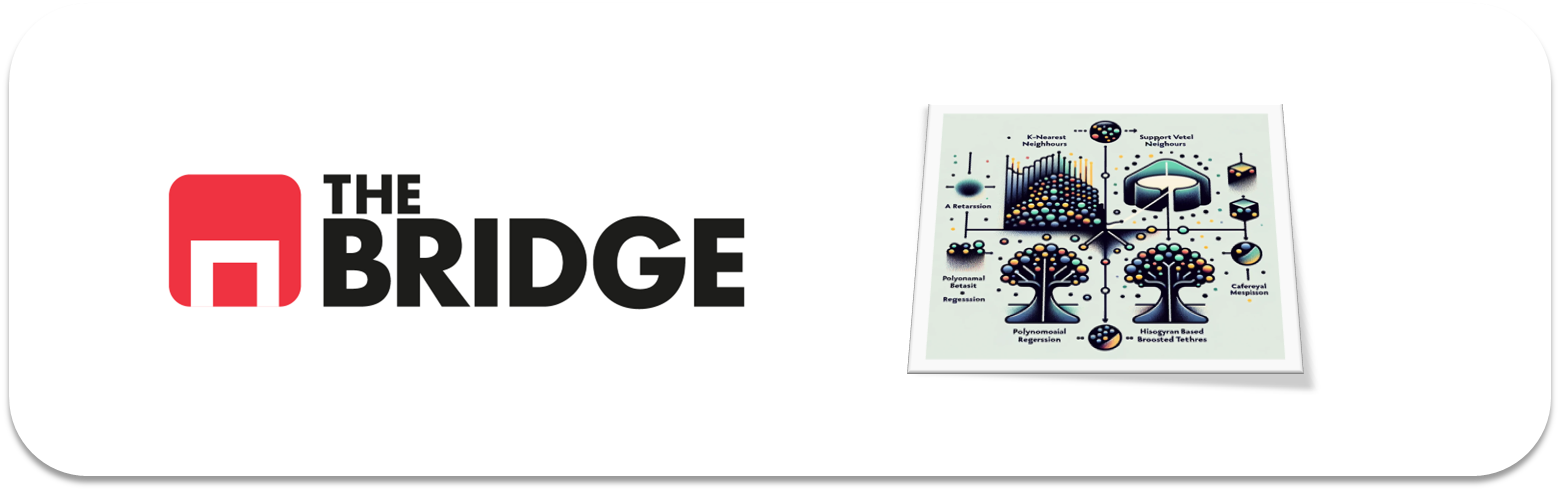

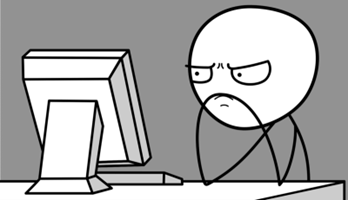

Para hacer un **repaso a los problemas de regresión con ML**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### INTRODUCCIóN: PROCESO DE ML

En los siguientes ejercicios vamos a seguir (de nuevo) los pasos básicos en la creación de un modelo de ML para resolver un problema de predicción a partir de un dataset que incluye el target, es decir, un aprendizaje supervisado.

En concreto, vamos a trabajar sobre un problema de clasificación a través de los siguientes pasos:

1. Entendimiento del problema (selección de la métrica más adecuada)  
2. Obtención de datos y primer contacto  
3. Train y Test  
4. MiniEDA: Análisis del target, análisis bivariante, entendimiento de las features, selección de las mismas (si es necesario)  
5. Preparación del dataset de Train: Conversión de categóricas, tratamiento de numéricas  
6. Selección e instanciación de modelos. Baseline.
7. Comparación de modelos (lo haremos por comparación con validación, puedes hacerlo por comparación de modelos de hiperparámetros optimizados, si así lo prefieres)  
8. Selección de modelo: Optimización de hiperparámetros (ten en cuenta la nota de 7)  
9. Evaluación contra test.  
10. Análisis de errores, posibles acciones futuras.  
11. EXTRA: Persistencia del modelo en disco.  

### El problema de Negocio

El ayuntamiento de Freehold, Nueva Jersey, está preocupado por los niveles de Ozono en situaciones de contaminación. Ha adquirido unos sensores muy potentes que permiten medir la composición de la calidad del aire casi en tiempo real, pero desgraciadamente la medida de Ozono se obtiene mucho más tarde (casi 12 horas después, este dato de las horas no es relevante para el problema). Las medidas son enviadas a una plataforma central donde se quiere incorporar un modelo que en función de esas medidas pueda predecir el nivel de $O_3$ (Ozono) en el aire y establecer alarmas y umbrales para avisar a la población o tomar medidas si es necesaria.

El concejal de urbanismo y tecnología, Bruce S., os contrata para que creéis ese modelo y para ello os suministra un dataset con medidas de la calidad de aire donde han incorporado el nivel de Ozono ("PT08.S5(O3)") posteriormente. Quieren un modelo que se equivoque en media en menos de 100 unidades por millón (la medida en la que tienen registrada la presencia de Ozono).

¡Manos a la obra!

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Ejercicio 1: Entendiendo el problema de "Negocio"

En función de la descripción del problema de "negocio" y sin mirar todavía los datos, ¿qué métricas creess más conveniente para medir el rendimiento del modelo a construir y, por tanto, para comparar posibles modelos entre sí?

regresion
target --> PT08.S1

### Ejercicio 2: Obtención y primer "vistazo"

Carga el dataset, muestra sus primeras filas, su descripción general y determina el tipo de variables que vamos a manejar. Escoge el target y crea una variable `target` y asignalé el nombre de la columna correspondiente.

In [2]:
df = pd.read_csv('./data/air_contamination.csv')
df.head()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8991 entries, 0 to 8990
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         8991 non-null   float64
 1   PT08.S1(CO)    8991 non-null   float64
 2   NMHC(GT)       8991 non-null   int64  
 3   C6H6(GT)       8991 non-null   float64
 4   PT08.S2(NMHC)  8991 non-null   float64
 5   NOx(GT)        8991 non-null   float64
 6   PT08.S3(NOx)   8991 non-null   float64
 7   NO2(GT)        8991 non-null   float64
 8   PT08.S4(NO2)   8991 non-null   float64
 9   PT08.S5(O3)    8991 non-null   float64
 10  T              8991 non-null   float64
 11  RH             8991 non-null   float64
 12  AH             8991 non-null   float64
dtypes: float64(12), int64(1)
memory usage: 913.3 KB


In [4]:
df.describe()

,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,-34.897053,1099.707856,-158.702591,10.082993,939.029205,163.732788,835.370973,56.654087,1456.143486,1022.780725,18.316054,49.232360,1.025530
std,78.202259,217.084571,140.680200,7.449640,266.829000,252.081877,256.815106,126.902274,346.204540,398.480897,8.832888,17.316389,0.403813
min,-200.000000,647.250000,-200.000000,0.149048,383.250000,-200.000000,322.000000,-200.000000,551.000000,221.000000,-1.900000,9.175000,0.184679
25%,0.600000,936.750000,-200.000000,4.436942,734.375000,49.000000,657.875000,52.000000,1226.625000,731.375000,11.787500,35.812500,0.736769
50%,1.500000,1063.000000,-200.000000,8.239851,909.000000,139.800000,805.500000,96.000000,1462.750000,963.250000,17.750000,49.550000,0.995395
75%,2.600000,1231.250000,-200.000000,13.988478,1116.250000,280.000000,969.250000,132.000000,1673.500000,1273.375000,24.400000,62.500001,1.313701
max,11.900000,2039.750000,1189.000000,63.741476,2214.000000,1479.000000,2682.750000,332.600000,2775.000000,2522.750000,44.600000,88.725000,2.231036


In [5]:
target = "PT08.S5(O3)"

### Ejercicio 3: Split

Haz el split en train y test.

In [6]:
X = df.drop(columns=[target])
y= df[target]

split_idx= int(len(df)*0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Tamaño train:", X_train.shape, y_train.shape)
print("Tamaño test:", X_test.shape, y_test.shape)


Tamaño train: (7192, 12) (7192,)
Tamaño test: (1799, 12) (1799,)


### Ejercicio 4: MiniEDA (I)

Analiza la distribución del target brevemente.

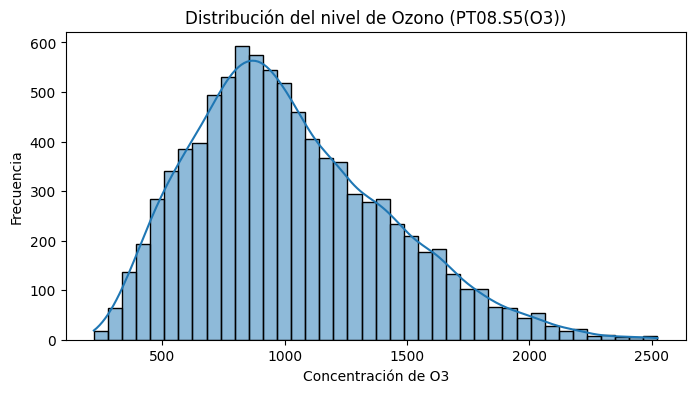

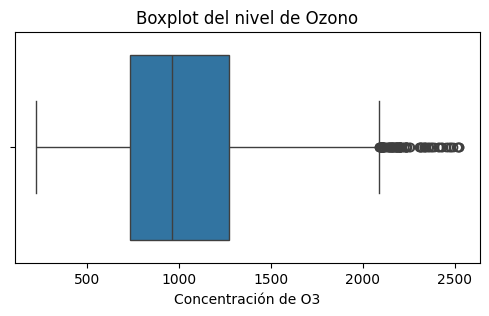

count    8991.000000
mean     1022.780725
std       398.480897
min       221.000000
25%       731.375000
50%       963.250000
75%      1273.375000
max      2522.750000
Name: PT08.S5(O3), dtype: float64

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histograma
plt.figure(figsize=(8,4))
sns.histplot(df[target], kde=True, bins=40)
plt.title("Distribución del nivel de Ozono (PT08.S5(O3))")
plt.xlabel("Concentración de O3")
plt.ylabel("Frecuencia")
plt.show()

# Boxplot para ver outliers
plt.figure(figsize=(6,3))
sns.boxplot(x=df[target])
plt.title("Boxplot del nivel de Ozono")
plt.xlabel("Concentración de O3")
plt.show()

# Estadísticos básicos
df[target].describe()

### Ejercicio 5: MiniEDA (II)

Analiza bivariantemente las variables contra el target, para las numéricas analiza la correlación numéricamente y gráficamente, para las categóricas analiza la distribución del target para cada valor de la categórica.

In [8]:
import numpy as np

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

# Quitamos el target de las listas
numeric_cols = [col for col in numeric_cols if col != target]

In [9]:
corr_with_target = df[numeric_cols + [target]].corr()[target].sort_values(ascending=False)
corr_with_target

PT08.S5(O3)      1.000000
PT08.S1(CO)      0.899326
PT08.S2(NMHC)    0.880590
C6H6(GT)         0.865727
NOx(GT)          0.622214
PT08.S4(NO2)     0.591137
NO2(GT)          0.338381
RH               0.124952
CO(GT)           0.122236
NMHC(GT)         0.111535
AH               0.070738
T               -0.027193
PT08.S3(NOx)    -0.796554
Name: PT08.S5(O3), dtype: float64

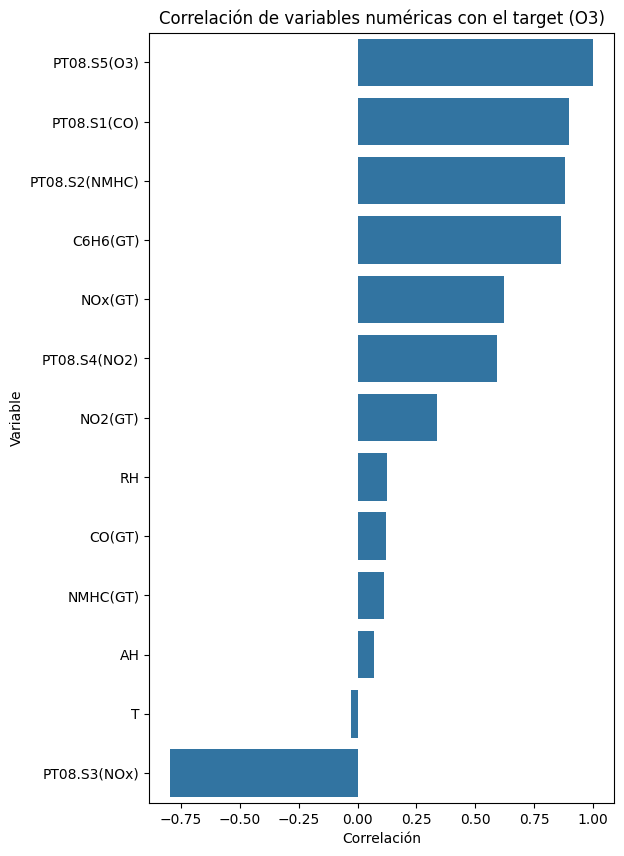

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,10))
sns.barplot(x=corr_with_target.values, y=corr_with_target.index)
plt.title("Correlación de variables numéricas con el target (O3)")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.show()

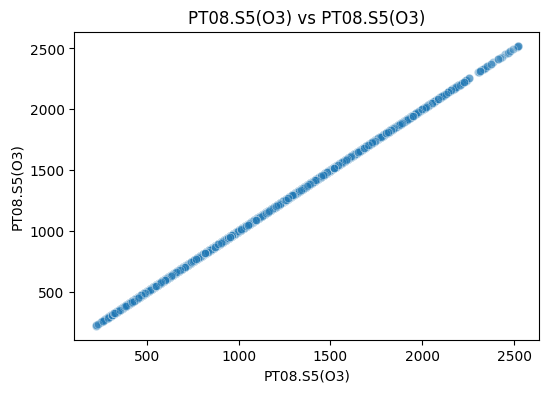

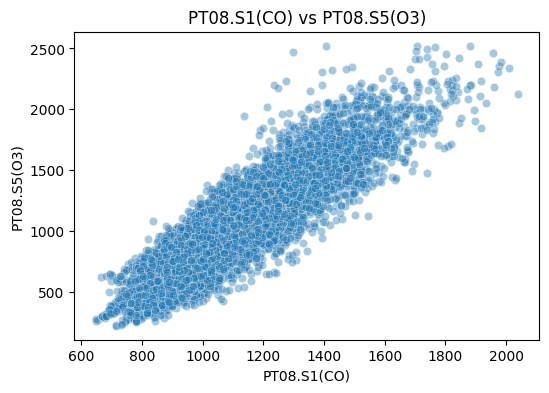

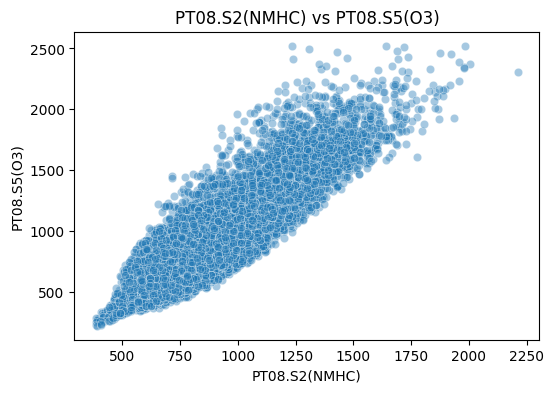

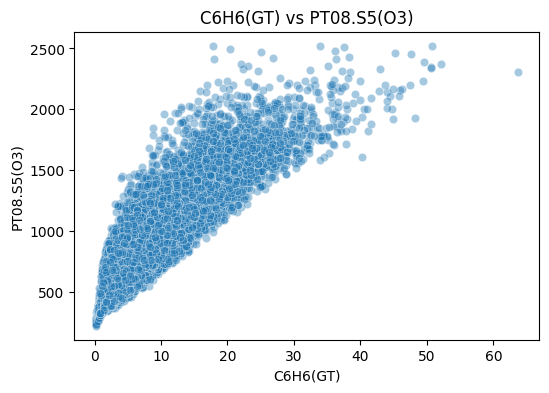

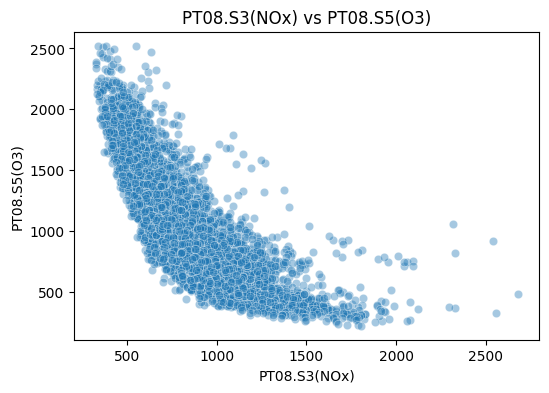

In [11]:
top5 = corr_with_target.abs().sort_values(ascending=False).head(5).index.tolist()

for col in top5:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df[target], alpha=0.4)
    plt.title(f"{col} vs {target}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.show()

### Ejercicio 6: MiniEDA (III)

Crea una variable de tipo lista a la que asignes los valores de las columnas que creas conveniente emplear como features en función de lo visto en el miniEDA. Haz una lista de modelos/algoritmos que vas a emplear para hacer el modelo (solo los nombres). En función de la lista anterior, ¿tienes que tratar las variables, por qué?

In [12]:
features = [
    'PT08.S1(CO)',
    'PT08.S2(NMHC)',
    'PT08.S3(NOx)',
    'PT08.S4(NO2)',
    'CO(GT)',
    'NMHC(GT)',
    'C6H6(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'T',
    'RH',
    'AH',
    
]


modelos = [
    "LinearRegression",
    "Ridge",
    "Lasso",
    "RandomForestRegressor",
    "GradientBoostingRegressor",
    "HistGradientBoostingRegressor",
    "XGBoostRegressor",
    "LightGBMRegressor",
    "SVR",
    "KNeighborsRegressor"
]

### Ejercicio 7: Tratamiento de features

Trata las features de manera que puedan ser empleadas por los modelos que escogite en el ejercicio anterior. Recuerda que este es un paso necesario porque los modelos no entienden de primeras de "letras" (salvo alguno que no es que entienda sino que hace sus transformaciones por dentro) y porque en determinados algoritmos es necesario que los rangos de las features estén escalados para que el algoritmo no se decante (érroneamente) por alguna feature sólo porque sus valores son mayores en rango que el de otras. NOTA: Recuerda que lo que le hagas al train, se lo tienes que hacer al test

In [13]:
df = df.replace(-200, pd.NA)

In [14]:
df = df.dropna(subset=[target])

In [15]:
X = df[features]
y = df[target]

In [16]:
import numpy as np

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [18]:
# Concatenamos X y y para eliminar filas completas con nulos
df_model = pd.concat([X, y], axis=1)

# Eliminamos filas con nulos en features o target
df_model = df_model.dropna()

# Separamos de nuevo
X = df_model[features]
y = df_model[target]

In [19]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx].copy()
X_test  = X.iloc[split_idx:].copy()
y_train = y.iloc[:split_idx].copy()
y_test  = y.iloc[split_idx:].copy()

In [20]:
preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

In [21]:
# Imputación simple: numéricas con la media, categóricas con la moda
from sklearn.impute import SimpleImputer

# Imputadores separados
num_imputer = SimpleImputer(strategy="mean")
cat_imputer = SimpleImputer(strategy="most_frequent")

# Aplicar a train
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])

# Aplicar a test con los mismos imputadores
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

In [22]:
# Ajustar con train
preprocessor.fit(X_train)

# Transformar train y test
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

### Ejercicio 8: Creación de los dataset de train y test

Crea las parejas X,y de train y test.

In [23]:
# Parejas de entrenamiento
X_train_final = X_train_prep
y_train_final = y_train

# Parejas de test
X_test_final = X_test_prep
y_test_final = y_test

In [24]:
print("Train:", X_train_final.shape, y_train_final.shape)
print("Test:", X_test_final.shape, y_test_final.shape)

Train: (661, 852) (661,)
Test: (166, 852) (166,)


### Ejercicios 9:

Importa e instancia los modelos que hayas escogido en el ejercicio 6. En general, no hace falta que asignes ahora ningún hiperparámetro salvo en los basados en árboles en los que debes escoger un max_depth para evitar el sobreajuste inicial. 

In [25]:
!pip install xgboost
!pip install lightgbm


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor



### Ejercicio 10: Comparativa de modelos

Haz la comparativa de modelos empleando cross_val_score (es decir la validación cruzada). Utiliza k = 5, y un scoring acorde a la métrica escogida en el ejercicio 1. Si no tienes clara la métrica entonces emplea "mean_absolute_error" (recuerda el funcionamiento del scoring en "sklearn", no te valdrá poner "mean_absolute_error"). Escoge el modelo ganador.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

# DEFINICIÓN CORRECTA: Objetos instanciados con el método .fit()
modelos = [
    LinearRegression(), 
    RandomForestRegressor(n_estimators=100)
]

for modelo in modelos:
    # Ahora 'modelo' es un objeto, no un string
    scores = cross_val_score(
        modelo, 
        X_train_final, 
        y_train_final, 
        cv=5, 
        scoring="neg_mean_absolute_error"
    )
    
    # Accedemos dinámicamente al nombre de la clase del objeto para el reporte
    nombre_modelo = modelo.__class__.__name__
    mae_promedio = -scores.mean()
    
    print(f"Modelo {nombre_modelo}: MAE medio = {mae_promedio:.2f}")

Modelo LinearRegression: MAE medio = 199.93
Modelo RandomForestRegressor: MAE medio = 105.52


### Ejercicio 11: Ajuste de hiperparámetros

Escoge un grid para ajustar los hiperparámetros de tu modelo. Crea un objeto GridSearch y "ajustalo" (emplea su método fit) para encontrar la mejor combinaciónde hiperparámetros empleando la métrica que decidimos en el ejercio 1. Si no lo tienes claro emplea "mean absolute error". 

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# 1. Definición del Espacio de Búsqueda (Hyperparameter Space)
# Seleccionamos parámetros críticos que controlan la complejidad y el sesgo del modelo
param_grid = {
    'n_estimators': [100, 200],         # Número de árboles en el ensamble
    'max_depth': [None, 10, 20],        # Profundidad máxima para controlar el sobreajuste
    'min_samples_split': [2, 5, 10],    # Mínimo de muestras para dividir un nodo interno
    'bootstrap': [True]                 # Método de muestreo
}

# 2. Inicialización del Estimador
rf_model = RandomForestRegressor(random_state=42)

# 3. Configuración del Objeto GridSearchCV
# Empleamos 'neg_mean_absolute_error' para alinearnos con tu métrica de referencia
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,                               # K-fold Cross Validation (k=5)
    scoring='neg_mean_absolute_error',
    n_jobs=-1,                          # Paralelización para eficiencia computacional
    verbose=2
)

# 4. Ajuste del Modelo (Fit)
# El proceso buscará la combinación óptima que minimice el MAE
grid_search.fit(X_train_final, y_train_final)

# 5. Extracción de Resultados Científicos
print(f"Mejor combinación de parámetros: {grid_search.best_params_}")
print(f"Mejor MAE (negativo): {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejor combinación de parámetros: {'bootstrap': True, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Mejor MAE (negativo): -105.9138


### Ejercicio 12: Evaluación del modelo

Evalúa el modelo contra el dataset de test. Muestra el informe de clasificación y haz una valoración de si el hospital aceptaría el modelo o no.

In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Inferencia sobre el conjunto de test
y_pred = grid_search.best_estimator_.predict(X_test_final)

# 2. Cálculo de métricas de rendimiento (Regression Metrics)
mae = mean_absolute_error(y_test_final, y_pred)
mse = mean_squared_error(y_test_final, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_final, y_pred)

print("--- Informe de Rendimiento del Modelo (Test Set) ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")

--- Informe de Rendimiento del Modelo (Test Set) ---
Mean Absolute Error (MAE): 100.6095
Root Mean Squared Error (RMSE): 130.5026
Coeficiente de Determinación (R²): 0.9119


### Ejercicio 13: Análisis de errores

Comparar los valores predichos contra los reales mediante una gráfica (puedes emplear la función que empleamos en el workout de la unidad anterior). Haz un pequeño análisis.

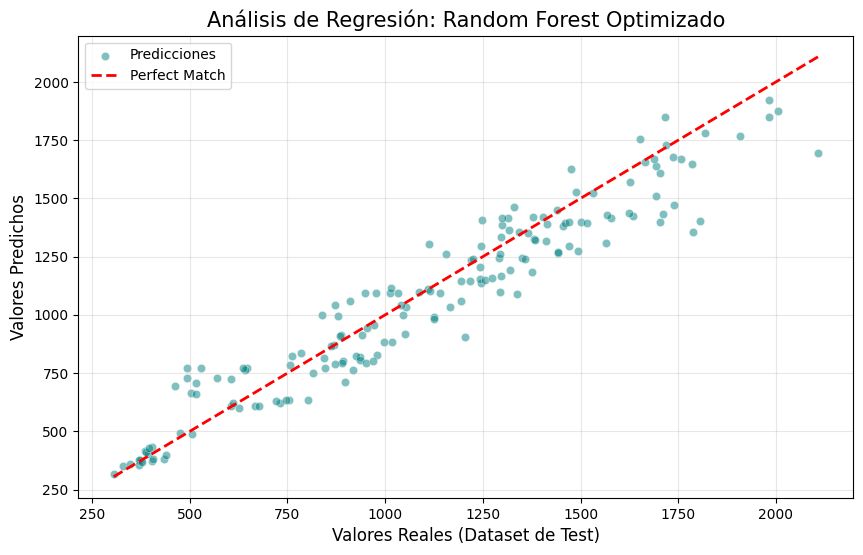

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_real_vs_pred(y_true, y_pred, model_name):
    plt.figure(figsize=(10, 6))
    
    # Scatter plot de los puntos
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.5, color='teal', label='Predicciones')
    
    # Línea de referencia (Predicción Perfecta y = x)
    max_val = max(max(y_true), max(y_pred))
    min_val = min(min(y_true), min(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Perfect Match')
    
    plt.title(f'Análisis de Regresión: {model_name}', fontsize=15)
    plt.xlabel('Valores Reales (Dataset de Test)', fontsize=12)
    plt.ylabel('Valores Predichos', fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Ejecución de la visualización
plot_real_vs_pred(y_test_final, y_pred, "Random Forest Optimizado")

### EXTRA: 

Busca en Internet o pregúntale a tu AI preferida, cómo se graba un modelo en disco y gúardalo en "./models/o3_pred" con la extesión apropiada.

In [34]:
import joblib
import os

# 1. Definición de la ruta y creación del directorio de modelos
model_dir = "./models"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    print(f"Directorio de persistencia creado: {model_dir}")

# 2. Ruta completa del archivo con la extensión estándar (.joblib)
model_path = os.path.join(model_dir, "o3_pred.joblib")

# 3. Serialización del mejor estimador (Best Estimator)
# Se utiliza el modelo optimizado en la etapa de ajuste (fit) previa
joblib.dump(grid_search.best_estimator_, model_path)

print(f"Modelo exportado exitosamente en: {model_path}")

Modelo exportado exitosamente en: ./models\o3_pred.joblib
